# Working with custom data

We can supply an object that represents custom data to the `PSVCurve` class. This can be helpful, if we want to represent a special structure in the data, for example stratified samples. The custom data have to represented by an object, that has a routine called `inject_into_model`, which takes the PSV curve knots and magnetic field vector at the knots as input. In the following, we will sketch an example for stratified data.

First we import some modules and use the same synthetic data as before.

In [1]:
import numpy as np
from pandas import DataFrame

from matplotlib import pyplot as plt

import pymc as pm
from pytensor import tensor as pt

from pypsv import PSVCurve
from pypsv.utils import interp
from pypsv.output import generate_curve_output
from pypsv.plotting_helpers import add_input_data_to_ax
from pypsv.convergence_report import calc_summary_and_print_diagnostics


input_data = DataFrame(
    data={
        'F': [40, 45],
        'dF': [1.25, 0.7],
        'Age': [879., 1595.],
        'dAge': [20, np.nan],
        'Age type': ["14C SH", "absolute"],
    },
)

# Fiji latitude and longitude
loc = (-18.166667, 178.45)
curve_knots = np.arange(900, 2001, 20)

Next, we define a class that contains three ordered records with uniform distributions. One is a value of 32 ± 1μT measured at 1040 CE ± 50, one gives a value of 35 ± 1μT measured at 1110 CE ± 70 and the last one a value of 38 ± 0.4 μT at 1200 CE ± 50. There is also a second measurement from the second layer, i.e. it shares the age of 1110 CE ± 70, but gives a value of 38 ± 0.4 μT

In [2]:
class StratifiedData():
    def __init__(self):
        # This is the data we model. It could also be part of the function...
        self.t1 = 1040
        self.dt1 = 50
        self.t2 = 1110
        self.dt2 = 70
        self.t3 = 1200
        self.dt3 = 50

        self.F = np.array([32., 35., 38.])
        self.dF = np.array([1., 1., 0.4])

        self.F_same_layer_as_t2 = np.array([38.])
        self.dF_same_layer_as_t2 = np.array([0.4])

    def inject_into_model(self, knots, nez_at_knots):
        # Define probability distribution for the age of the first record
        t_1_uni = pm.Uniform(
            'custom_t_uniform_1',
            lower=0.,
            upper=1.,
            size=1,
        )
        width = 2 * self.dt1
        offset = self.t1 - self.dt1
        t1 = pm.Deterministic(
            'custom_t_1',
            t_1_uni * width + offset,
        )

        # Define probability distribution for the age of the second record
        t_2_uni = pm.Uniform(
            'custom_t_uniform_2',
            lower=0.,
            upper=1.,
            size=1,
        )
        width = 2 * self.dt2
        offset = self.t2 - self.dt2
        t2 = pm.Deterministic(
            'custom_t_2',
            t_2_uni * width + offset,
        )

        # Define probability distribution for the age of the second record
        t_3_uni = pm.Uniform(
            'custom_t_uniform_3',
            lower=0.,
            upper=1.,
            size=1,
        )
        width = 2 * self.dt3
        offset = self.t3 - self.dt3
        t3 = pm.Deterministic(
            'custom_t_3',
            t_3_uni * width + offset,
        )

        # We use a soft constraint, in order to get smooth gradients.
        # This allows t2 to be smaller than t1, but with a very small
        # probability. We add a padding of 1 year. If we remove this, some
        # samples are actually inverted, i.e. t1 > t2
        soft_order_constraint = pm.math.log(
            pm.invlogit(
                2e2 * (t2 - t1 - 1) / (self.t2 - self.t1)
            )
        )

        bound = pm.Potential(
            'soft_order_constraint',
            soft_order_constraint,
        )

        soft_order_constraint_2 = pm.math.log(
            pm.invlogit(
                2e2 * (t3 - t2 - 1) / (self.t3 - self.t2)
            )
        )

        bound_2 = pm.Potential(
            'soft_order_constraint_2',
            soft_order_constraint_2,
        )

        # With the ages defined, we loop over the epochs and set up the
        # likelihood
        for it, _t in enumerate([t1, t2, t3]):
            nez_at_t = interp(
                _t,
                curve_knots,
                nez_at_knots,
            )
            f_at_t = pm.Deterministic(
                f'custom_f_at_t_{it+1}',
                pt.sqrt(
                    pt.sum(
                        pt.square(nez_at_t),
                        axis=1,
                    ),
                ),
            )

            rF = pm.Deterministic(
                f'custom_rF_{it+1}',
                (f_at_t - self.F[it]) / self.dF[it],
            )

            pm.StudentT(
                f'custom_f_obs_{it+1}',
                nu=4,
                mu=rF,
                sigma=1.,
                observed=[0],
            )
            if it == 1:
                rF_2 = pm.Deterministic(
                    f'custom_rF_also_at_{it+1}',
                    (f_at_t - self.F_same_layer_as_t2)
                    / self.dF_same_layer_as_t2,
                )

                pm.StudentT(
                    f'custom_f_also_at_obs_{it+1}',
                    nu=4,
                    mu=rF_2,
                    sigma=1.,
                    observed=[0],
                )

# Instantiate the class
custom_data = StratifiedData()

Next we set up a `PSVCurve` object and pass our custom data to the sampling routine:

In [3]:
curve = PSVCurve(
    loc=loc,
    curve_knots=curve_knots,
)
iData = curve.sample(
    data=input_data,
    custom_data=custom_data,
)

Reading data...
...done.
Setting up PyMC model...
...model setup done.


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

In [4]:
summary = calc_summary_and_print_diagnostics(iData)

The maximal treedepth was 8.
The chains had 0 divergences.
There were 0 random variables with rhat > 1.10.
Effective sample size ratio estimations:
            min / mean / max
from bulk: 0.47 / 1.44 / 2.45
from tail: 0.47 / 0.71 / 0.97



From the hexbin plot, we can see that actually t2 > t1 and t3 > t2. Without the padding, this wouldn't be the case for some of the samples.

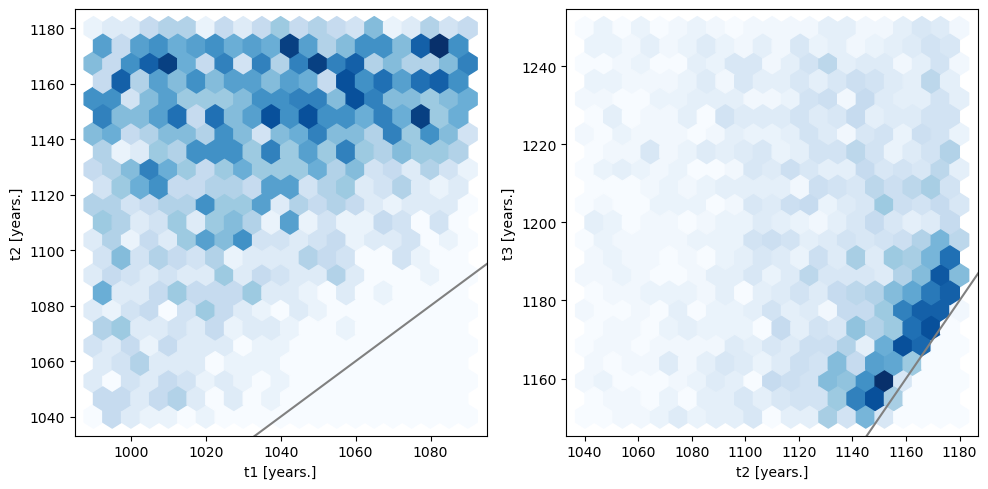

In [5]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(10, 5)
)
axs[0].hexbin(
    iData.posterior['custom_t_1'].values.flatten(),
    iData.posterior['custom_t_2'].values.flatten(),
    gridsize=20,
    cmap='Blues',
)
axs[0].set_xlabel('t1 [years.]')
axs[0].set_ylabel('t2 [years.]')

axs[1].hexbin(
    iData.posterior['custom_t_2'].values.flatten(),
    iData.posterior['custom_t_3'].values.flatten(),
    gridsize=20,
    cmap='Blues',
)
for ax in axs:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    ax.plot(
        np.linspace(1000, 2000, 201),
        np.linspace(1000, 2000, 201),
        color='grey',
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

axs[1].set_xlabel('t2 [years.]')
axs[1].set_ylabel('t3 [years.]')

fig.tight_layout()

In [6]:
knots, curve_samples = generate_curve_output(iData, thin=2)

Text(0, 0.5, 'F [$\\mu$T]')

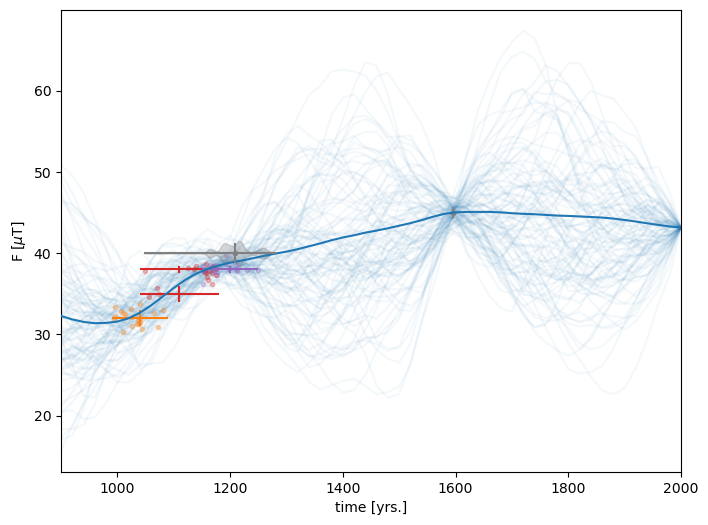

In [7]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 6),
)

ax.plot(
    knots,
    curve_samples['F'].mean(axis=1),
    color='C0',
    zorder=5,
)
ax.plot(
    knots,
    curve_samples['F'][:, ::10],
    color='C0',
    alpha=0.05,
    zorder=0,
)

ax.errorbar(
    custom_data.t1,
    custom_data.F[0],
    xerr=custom_data.dt1,
    yerr=custom_data.dF[0],
    color='C1',
)
ax.scatter(
    iData.posterior['custom_t_1'].values.flatten()[:20],
    iData.posterior['custom_f_at_t_1'].values.flatten()[:20],
    color='C1',
    marker='.',
    alpha=0.3,
)
ax.errorbar(
    custom_data.t2,
    custom_data.F[1],
    xerr=custom_data.dt2,
    yerr=custom_data.dF[1],
    color='C3',
)
ax.scatter(
    iData.posterior['custom_t_2'].values.flatten()[:20],
    iData.posterior['custom_f_at_t_2'].values.flatten()[:20],
    color='C3',
    marker='.',
    alpha=0.3,
)
ax.errorbar(
    custom_data.t2,
    custom_data.F_same_layer_as_t2,
    xerr=custom_data.dt2,
    yerr=custom_data.dF_same_layer_as_t2,
    color='C3',
)
ax.errorbar(
    custom_data.t3,
    custom_data.F[2],
    xerr=custom_data.dt3,
    yerr=custom_data.dF[2],
    color='C4',
)
ax.scatter(
    iData.posterior['custom_t_3'].values.flatten()[:20],
    iData.posterior['custom_f_at_t_3'].values.flatten()[:20],
    color='C4',
    marker='.',
    alpha=0.3,
)

add_input_data_to_ax(
    ax,
    input_data,
    'F',
    color='grey',
)
ax.set_xlim(min(knots), max(knots))
# ax.set_ylim(35, 60)
ax.set_xlabel('time [yrs.]')
ax.set_ylabel(r'F [$\mu$T]')